In [1]:
import pandas as pd


df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")


print(df.head())


print("Shape:", df.shape)

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

In [3]:

print(df.info())


print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
# Normalize function
def normalize(col):
    return (col - col.min()) / (col.max() - col.min())

# KPI 1: Task Completion Time (lower is better)
df['TaskCompletionScore'] = 1 - normalize(df['YearsInCurrentRole'])

# KPI 2: Project Quality
df['ProjectQualityScore'] = (
    normalize(df['PerformanceRating']) +
    normalize(df['JobSatisfaction'])
) / 2

# KPI 3: Mentor Feedback
df['MentorFeedbackScore'] = (
    normalize(df['EnvironmentSatisfaction']) +
    normalize(df['RelationshipSatisfaction'])
) / 2

# Overall Score
df['OverallPerformance'] = (
    df['TaskCompletionScore'] +
    df['ProjectQualityScore'] +
    df['MentorFeedbackScore']
) / 3

print(df[['TaskCompletionScore','ProjectQualityScore','MentorFeedbackScore','OverallPerformance']].head())

   TaskCompletionScore  ProjectQualityScore  MentorFeedbackScore  \
0             0.777778             0.500000             0.166667   
1             0.611111             0.666667             0.833333   
2             1.000000             0.333333             0.666667   
3             0.611111             0.333333             0.833333   
4             0.888889             0.166667             0.500000   

   OverallPerformance  
0            0.481481  
1            0.703704  
2            0.666667  
3            0.592593  
4            0.518519  


In [7]:
def performance_label(score):
    if score >= 0.75:
        return "High Performer"
    elif score >= 0.5:
        return "Average"
    else:
        return "Low Performer"

df['PerformanceCategory'] = df['OverallPerformance'].apply(performance_label)

print(df['PerformanceCategory'].value_counts())

PerformanceCategory
Average           912
Low Performer     432
High Performer    126
Name: count, dtype: int64


In [9]:

df.to_csv("processed_intern_performance.csv", index=False)

In [11]:
report = df.groupby('PerformanceCategory').agg({
    'OverallPerformance': 'mean',
    'EmployeeNumber': 'count'
}).rename(columns={'EmployeeNumber': 'TotalEmployees'})

print(report)

                     OverallPerformance  TotalEmployees
PerformanceCategory                                    
Average                        0.609162             912
High Performer                 0.811287             126
Low Performer                  0.408265             432


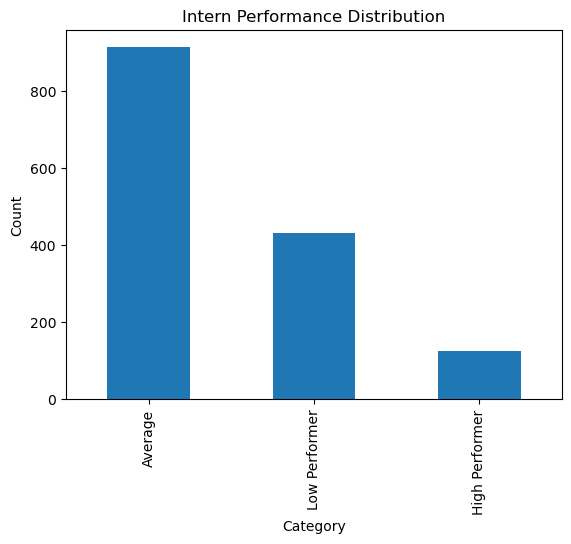

In [13]:
import matplotlib.pyplot as plt

df['PerformanceCategory'].value_counts().plot(kind='bar')
plt.title("Intern Performance Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()